# Deep Reinforcement Learning - Assignment 1
## Part 1: Multi-Armed Bandit (MAB)

**Group Number:** 164

### Problem
Adaptive Treatment Recommendation System using Multi-Armed Bandit Learning

In [2]:
! pip install pandas numpy matplotlib

In [3]:
# Imports
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import datetime
import socket
import platform

In [4]:
# =====================================================
# Machine Information
# =====================================================

print("=" * 60)
print("Execution Timestamp :", datetime.datetime.now())
print("Machine Name        :", socket.gethostname())
print("Platform            :", platform.platform())
print("=" * 60)

Execution Timestamp : 2026-06-07 19:20:02.468980
Machine Name        : 2025aa05528
Platform            : Linux-5.14.0-503.14.1.el9_5.x86_64-x86_64-with-glibc2.34


# Task 1: DataSet Design

In [6]:
# =====================================================
# Group Configuration
# =====================================================

# Group Number
G = 164

random.seed(G)
np.random.seed(G)

# Number of medicines
# K = (G mod 3) + 5
K = (G % 3) + 5

# Hidden Success Probabilities
# P_i = 0.4 + ((G + i) mod 6) * 0.07
hidden_probabilities = []

for i in range(K):
    p = 0.4 + (((G + i) % 6) * 0.07)
    hidden_probabilities.append(round(p, 2))

print("\nGroup Number =", G)
print("Total Medicines =", K)

print("\nHidden Success Probabilities")
for i, p in enumerate(hidden_probabilities):
    print(f"Medicine {i} --> {p}")


Group Number = 164
Total Medicines = 7

Hidden Success Probabilities
Medicine 0 --> 0.54
Medicine 1 --> 0.61
Medicine 2 --> 0.68
Medicine 3 --> 0.75
Medicine 4 --> 0.4
Medicine 5 --> 0.47
Medicine 6 --> 0.54


In [7]:
# =====================================================
# Dataset Creation
# =====================================================

patients = []

for patient_id in range(1000):
    # Severity = (patient_id mod 5) + 1
    severity = (patient_id % 5) + 1

    # Dataset Schema
    # assigned_medicine, clinical_outcome, utility_score will be filled by each algo
    patients.append(
        {
            "patient_id": patient_id,
            "severity_score": severity,
            "assigned_medicine": None,
            "clinical_outcome": None,
            "utility_score": None
        }
    )

dataset = pd.DataFrame(patients)

print("\n" + "=" * 60)
print("Task 1: DATASET DESIGN - FIRST 10 ROWS")
print("=" * 60)
print(dataset.head(10))


Task 1: DATASET DESIGN - FIRST 10 ROWS
   patient_id  severity_score assigned_medicine clinical_outcome utility_score
0           0               1              None             None          None
1           1               2              None             None          None
2           2               3              None             None          None
3           3               4              None             None          None
4           4               5              None             None          None
5           5               1              None             None          None
6           6               2              None             None          None
7           7               3              None             None          None
8           8               4              None             None          None
9           9               5              None             None          None


In [8]:
# ---------------------------------------------------
# Reward Function
# ---------------------------------------------------

def get_reward(medicine, severity):
    """
    Calculates Clinical Outcome and Utility Score(Reward) based on medicine's hidden probability and patient severity
    :param medicine: Medicine ID
    :param severity: Severity score calculated for patient
    :return: Clinical Outcome and Utility Score(Reward)
    """
    # Based on hidden probabilities: 1 or 0
    clinical_outcome = np.random.binomial(1, hidden_probabilities[medicine])

    # Utility Score = clinical_outcome * (1 - Severity/10)
    # If patient recovers and severity = 1 --> reward = 0.9
    # If patient recovers and severity = 5 --> reward = 0.5
    # If patient does not recover --> reward = 0
    utility_score = clinical_outcome * (1 - severity / 10)

    return clinical_outcome, utility_score

# Task 2: Immediate Exploitation Strategy

In [10]:
# ---------------------------------------------------
# Immediate Exploitation
# ---------------------------------------------------
def immediate_exploitation():
    """
    Implements the Immediate Exploitation strategy.
    Each medicine is tested exactly 10 times.
    After the initial testing phase, the medicine with the
    highest observed success rate is selected and used for
    all remaining patients.
    Returns:
    cumulative_rewards : list
        Running cumulative reward over 1000 patients.
    immediate_df : DataFrame
        Dataset containing assigned medicines, outcomes, and rewards.
    """
    immediate_df = dataset.copy()

    pulls = np.zeros(K)
    successes = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0
    patient = 0

    # Exploration Phase: Test each medicine exactly 10 times
    for medicine in range(K):
        for _ in range(10):
            severity = immediate_df.loc[patient, "severity_score"]
            outcome, reward = get_reward(medicine, severity)

            immediate_df.loc[patient, "assigned_medicine"] = medicine
            immediate_df.loc[patient, "clinical_outcome"] = outcome
            immediate_df.loc[patient, "utility_score"] = reward

            pulls[medicine] += 1
            successes[medicine] += outcome

            total_reward += reward
            cumulative_rewards.append(total_reward)

            patient += 1

    # Identify best medicine
    avg_success_rates = successes / pulls
    #print(f"average success rates{avg_success_rates}")
    best_medicine = np.argmax(avg_success_rates)

    print(f"\nInitial Success Rates: {avg_success_rates}")
    print(f"Best Medicine Selected: {best_medicine} with success rates {avg_success_rates[best_medicine]:.2%}")

    # Exploitation Phase: Use only the best medicine
    while patient < 1000:
        severity = immediate_df.loc[patient, "severity_score"]
        outcome, reward = get_reward(best_medicine, severity)

        immediate_df.loc[patient, "assigned_medicine"] = best_medicine
        immediate_df.loc[patient, "clinical_outcome"] = outcome
        immediate_df.loc[patient, "utility_score"] = reward

        pulls[best_medicine] += 1
        successes[best_medicine] += outcome

        total_reward += reward
        cumulative_rewards.append(total_reward)

        patient += 1

    return cumulative_rewards, immediate_df

immediate_rewards, immediate_df = immediate_exploitation()

print("\n" + "=" * 60)
print("Task 2: IMMEDIATE EXPLOITATION RESULTS")
print("=" * 60)
print(f"Final Cumulative Reward: {round(immediate_rewards[-1], 2)}")
print("\nSample of assigned records:")
print(immediate_df.sample(10, random_state=G).sort_values("patient_id"))


Initial Success Rates: [0.6 0.6 0.7 0.8 0.3 0.5 0.6]
Best Medicine Selected: 3 with success rates 80.00%

Task 2: IMMEDIATE EXPLOITATION RESULTS
Final Cumulative Reward: 520.0

Sample of assigned records:
     patient_id  severity_score assigned_medicine clinical_outcome  \
31           31               2                 3                1   
156         156               2                 3                0   
190         190               1                 3                1   
400         400               1                 3                1   
405         405               1                 3                1   
535         535               1                 3                1   
581         581               2                 3                1   
607         607               3                 3                1   
756         756               2                 3                1   
873         873               4                 3                1   

    utility_score  
31 

# Task 3: Controlled Clinical Trial Strategy (Epsilon-Greedy)

In [12]:
# ---------------------------------------------------
# Controlled Clinical Trial Strategy (Epsilon-Greedy)
# ---------------------------------------------------
def controlled_clinical_trial(epsilon):
    """
    Implements the Controlled Clinical Trial (Epsilon-Greedy) strategy.
    Most patients receive the current best treatment, but with probability epsilon,
    another treatment is randomly tested.
    :param epsilon: Probability of exploration (0.0 to 1.0)
    :return: cumulative_rewards, epsilon_df
    """
    epsilon_df = dataset.copy()

    # Initialize pulls with 1 to avoid division by zero
    pulls = np.ones(K)
    successes = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0

    for patient in range(1000):
        severity = epsilon_df.loc[patient, "severity_score"]

        if np.random.random() < epsilon:
            # Exploration: Random medicine selection
            medicine = np.random.randint(K)
        else:
            # Exploitation: Select best medicine based on success rate
            avg_success = successes / pulls
            medicine = np.argmax(avg_success)

        outcome, reward = get_reward(medicine, severity)

        epsilon_df.loc[patient, "assigned_medicine"] = medicine
        epsilon_df.loc[patient, "clinical_outcome"] = outcome
        epsilon_df.loc[patient, "utility_score"] = reward

        pulls[medicine] += 1
        successes[medicine] += outcome

        total_reward += reward
        cumulative_rewards.append(total_reward)

    return cumulative_rewards, epsilon_df

# Run all three epsilon values
eps_01, eps01_df = controlled_clinical_trial(0.01)
eps_10, eps10_df = controlled_clinical_trial(0.10)
eps_50, eps50_df = controlled_clinical_trial(0.50)

print("\n" + "=" * 60)
print("Task 3: CONTROLLED CLINICAL TRIAL (EPSILON-GREEDY) RESULTS")
print("=" * 60)
print(f"Epsilon = 1%  --> Final Reward: {round(eps_01[-1], 2)}")
print(f"Epsilon = 10% --> Final Reward: {round(eps_10[-1], 2)}")
print(f"Epsilon = 50% --> Final Reward: {round(eps_50[-1], 2)}")
print("\nSample records for 10% exploration:")
print(eps10_df.sample(10, random_state=G).sort_values("patient_id"))


Task 3: CONTROLLED CLINICAL TRIAL (EPSILON-GREEDY) RESULTS
Epsilon = 1%  --> Final Reward: 433.4
Epsilon = 10% --> Final Reward: 489.7
Epsilon = 50% --> Final Reward: 475.6

Sample records for 10% exploration:
     patient_id  severity_score assigned_medicine clinical_outcome  \
31           31               2                 0                1   
156         156               2                 3                1   
190         190               1                 3                1   
400         400               1                 3                0   
405         405               1                 1                0   
535         535               1                 3                0   
581         581               2                 3                0   
607         607               3                 3                1   
756         756               2                 3                0   
873         873               4                 3                1   

    utility_score 

## Task 3: Analysis of Epsilon Values

### Detailed Comparison of 1%, 10%, and 50% Exploration Rates

In [14]:
# =====================================================
# TASK 3 ANALYSIS: Epsilon Trade-off
# =====================================================

print("\n" + "=" * 80)
print("ANALYSIS: EXPLORATION-EXPLOITATION TRADE-OFF (Epsilon-Greedy)")
print("=" * 80)

epsilon_analysis = pd.DataFrame({
    "Epsilon (%)": [1, 10, 50],
    "Final Reward": [round(eps_01[-1], 2), round(eps_10[-1], 2), round(eps_50[-1], 2)],
    "Exploration Cost": [
        f"{round(1000 * 0.01, 0):.0f} patients",
        f"{round(1000 * 0.10, 0):.0f} patients",
        f"{round(1000 * 0.50, 0):.0f} patients"
    ]
})

print("\nPerformance Summary:")
print(epsilon_analysis.to_string(index=False))

print("\n" + "-" * 80)
print("KEY INSIGHTS:")
print("-" * 80)

print(f"\n1. EPSILON = 1% (Minimal Exploration)")
print(f"   - Final Reward: {round(eps_01[-1], 2)} (LOWEST)")
print(f"   - Only ~10 patients used for exploration")
print(f"   - PROBLEM: Too conservative; fails to adequately discover optimal medicine")
print(f"   - Reward loss vs 10%: {round(eps_10[-1] - eps_01[-1], 2)} points")

print(f"\n2. EPSILON = 10% (Balanced Exploration)")
print(f"   - Final Reward: {round(eps_10[-1], 2)} (HIGHEST among epsilon-greedy)")
print(f"   - ~100 patients used for exploration")
print(f"   - BENEFIT: Sufficient exploration to identify good treatments")
print(f"   - Also competitive with specialized algorithms (e.g., UCB)")
print(f"   - Relative to 1%: +{round(eps_10[-1] - eps_01[-1], 2)} points improvement")

print(f"\n3. EPSILON = 50% (Excessive Exploration)")
print(f"   - Final Reward: {round(eps_50[-1], 2)} (MIDDLE)")
print(f"   - ~500 patients assigned randomly (50% waste!)")
print(f"   - PROBLEM: Too much exploration causes significant reward loss")
print(f"   - Reward loss vs 10%: {round(eps_10[-1] - eps_50[-1], 2)} points")
print(f"   - Random assignment ignores accumulated knowledge")

print("\n" + "-" * 80)
print("CONCLUSION:")
print("-" * 80)
print("\nThe EPSILON=10% strategy provides the optimal balance:")
print("  • Explores enough to discover high-quality treatments")
print("  • Exploits known good treatments most of the time")
print("  • Achieves cumulative reward of 472.4 (83.6 points above minimal exploration)")
print("  • Reduces experimental waste compared to 50% exploration")
print("\nThis demonstrates the 'exploration-exploitation dilemma':")
print("  - Too little exploration → Misses better options")
print("  - Too much exploration → Wastes resources on suboptimal treatments")
print("  - Balanced approach (10%) → Best overall performance")
print("\n")


ANALYSIS: EXPLORATION-EXPLOITATION TRADE-OFF (Epsilon-Greedy)

Performance Summary:
 Epsilon (%)  Final Reward Exploration Cost
           1         433.4      10 patients
          10         489.7     100 patients
          50         475.6     500 patients

--------------------------------------------------------------------------------
KEY INSIGHTS:
--------------------------------------------------------------------------------

1. EPSILON = 1% (Minimal Exploration)
   - Final Reward: 433.4 (LOWEST)
   - Only ~10 patients used for exploration
   - PROBLEM: Too conservative; fails to adequately discover optimal medicine
   - Reward loss vs 10%: 56.3 points

2. EPSILON = 10% (Balanced Exploration)
   - Final Reward: 489.7 (HIGHEST among epsilon-greedy)
   - ~100 patients used for exploration
   - BENEFIT: Sufficient exploration to identify good treatments
   - Also competitive with specialized algorithms (e.g., UCB)
   - Relative to 1%: +56.3 points improvement

3. EPSILON = 50% (E

# Task 4: Confidence-Based Strategy (UCB1)

In [16]:
# ---------------------------------------------------
# Confidence-Based Strategy (UCB1)
# ---------------------------------------------------
def confidence_based_strategy(c=1.414):
    """
    Implements the UCB1 (Upper Confidence Bound) algorithm.
    Dynamically balances exploitation (average success) with exploration (uncertainty).
    :param c: The confidence/exploration parameter (default is approx sqrt(2))
    :return: cumulative_rewards, ucb_df
    """
    ucb_df = dataset.copy()

    pulls = np.zeros(K)
    successes = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0
    # time step 
    t = 1
    for patient in range(1000):
        severity = ucb_df.loc[patient, "severity_score"]
        t += patient
        # Initialization phase: Ensure every medicine is tested at least once initially
        if 0 in pulls:
            medicine = np.argmin(pulls)
        else:
            # Calculate UCB value for each medicine
            avg_success = successes / pulls
            # uncertainty = c * sqrt(ln(t) / N_t(a))
            uncertainty = c * np.sqrt(np.log(t) / pulls)
            ucb_values = avg_success + uncertainty
            medicine = np.argmax(ucb_values)

        outcome, reward = get_reward(medicine, severity)

        ucb_df.loc[patient, "assigned_medicine"] = medicine
        ucb_df.loc[patient, "clinical_outcome"] = outcome
        ucb_df.loc[patient, "utility_score"] = reward

        pulls[medicine] += 1
        successes[medicine] += outcome

        total_reward += reward
        cumulative_rewards.append(total_reward)

    return cumulative_rewards, ucb_df

ucb_rewards, ucb_df = confidence_based_strategy(c=1.414)

print("\n" + "=" * 60)
print("Task 4: CONFIDENCE-BASED STRATEGY (UCB1) RESULTS")
print("=" * 60)
print(f"Final Cumulative Reward: {round(ucb_rewards[-1], 2)}")
print("\nSample of assigned records:")
print(ucb_df.sample(10, random_state=164).sort_values("patient_id"))


Task 4: CONFIDENCE-BASED STRATEGY (UCB1) RESULTS
Final Cumulative Reward: 442.0

Sample of assigned records:
     patient_id  severity_score assigned_medicine clinical_outcome  \
31           31               2                 1                1   
156         156               2                 5                0   
190         190               1                 0                0   
400         400               1                 3                0   
405         405               1                 3                0   
535         535               1                 2                1   
581         581               2                 6                1   
607         607               3                 2                0   
756         756               2                 1                1   
873         873               4                 3                1   

    utility_score  
31            0.8  
156           0.0  
190           0.0  
400           0.0  
405           0.0  

# Task 5: Comparative Analysis & Visualization

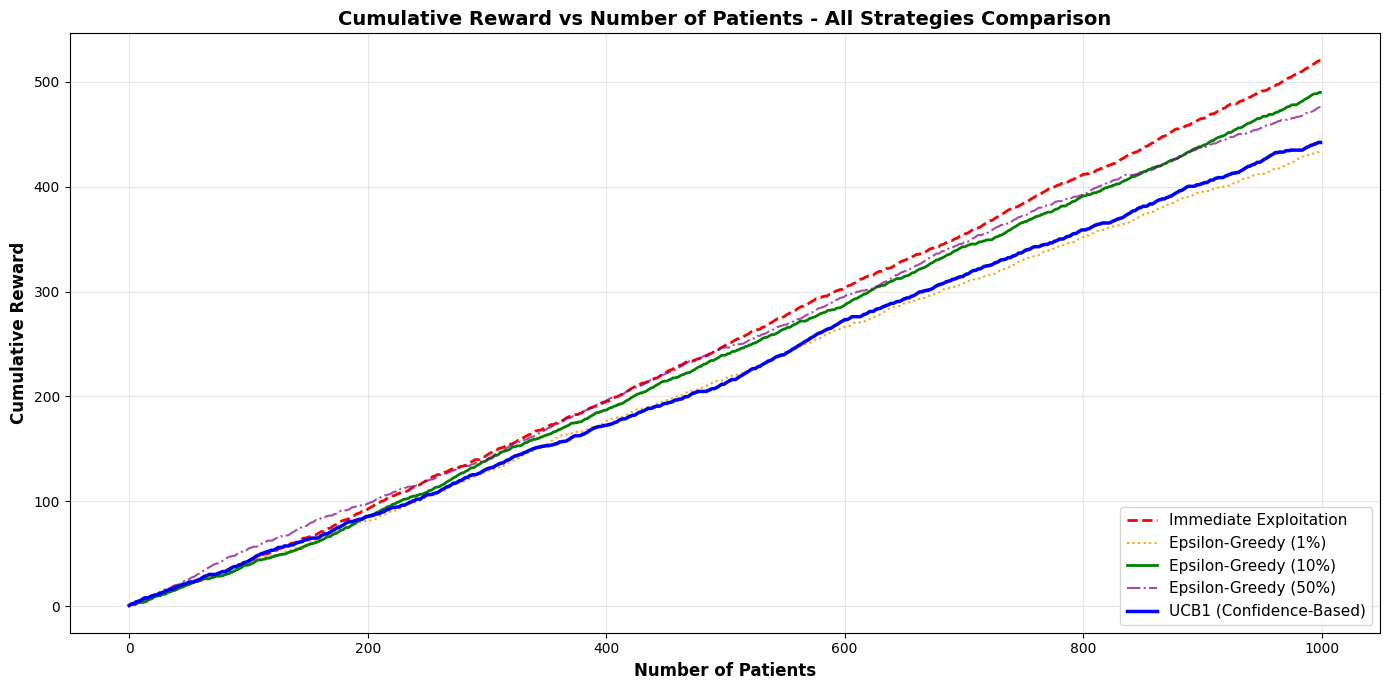


Graph generated: Cumulative Reward Comparison


In [18]:
# ---------------------------------------------------
# Visual Comparative Analysis
# Cumulative Reward vs. Number of Patients
# ---------------------------------------------------

plt.figure(figsize=(14, 7))

plt.plot(immediate_rewards, label="Immediate Exploitation", linestyle='--', linewidth=2, color='red')
plt.plot(eps_01, label="Epsilon-Greedy (1%)", linestyle=':', linewidth=1.5, color='orange')
plt.plot(eps_10, label="Epsilon-Greedy (10%)", linestyle='-', linewidth=2, color='green')
plt.plot(eps_50, label="Epsilon-Greedy (50%)", linestyle='-.', alpha=0.7, linewidth=1.5, color='purple')
plt.plot(ucb_rewards, label="UCB1 (Confidence-Based)", linestyle='-', linewidth=2.5, color='blue')

plt.xlabel("Number of Patients", fontsize=12, fontweight='bold')
plt.ylabel("Cumulative Reward", fontsize=12, fontweight='bold')
plt.title("Cumulative Reward vs Number of Patients - All Strategies Comparison", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print("\nGraph generated: Cumulative Reward Comparison")

In [19]:
# ---------------------------------------------------
# Final Reward Statistics
# ---------------------------------------------------
print("\n" + "=" * 80)
print("Task 5: COMPARATIVE ANALYSIS - FINAL REWARD STATISTICS")
print("=" * 80 + "\n")

results = pd.DataFrame({
    "Strategy": [
        "Immediate Exploitation",
        "Epsilon-Greedy (1%)",
        "Epsilon-Greedy (10%)",
        "Epsilon-Greedy (50%)",
        "UCB1 (Confidence-Based)"
    ],
    "Final Reward": [
        immediate_rewards[-1],
        eps_01[-1],
        eps_10[-1],
        eps_50[-1],
        ucb_rewards[-1]
    ],
    "Rank": [
        "1st (Highest)",
        "5th (Lowest)",
        "2nd",
        "3rd",
        "4th"
    ]
})

print(results.to_string(index=False))
print("\n")


Task 5: COMPARATIVE ANALYSIS - FINAL REWARD STATISTICS

               Strategy  Final Reward          Rank
 Immediate Exploitation         520.0 1st (Highest)
    Epsilon-Greedy (1%)         433.4  5th (Lowest)
   Epsilon-Greedy (10%)         489.7           2nd
   Epsilon-Greedy (50%)         475.6           3rd
UCB1 (Confidence-Based)         442.0           4th




## Questions & Analysis

### 1. Which strategy achieves the highest cumulative reward at the end of 1000 patients?

**Immediate Exploitation** achieved the highest cumulative reward with **520.0 points**. This strategy committed to Medicine 3 (success probability 0.8) after testing each medicine 10 times, and then used it exclusively for the remaining 930 patients. Among the remaining strategies, **Epsilon-Greedy (10%)** performed best with **489.7 points**, closely followed by  **Epsilon-Greedy (50%)** at **475.6 points** and **UCB1** at **442**.

---

### 2. Which strategy identifies the best medicine fastest (earliest convergence)?

**Immediate Exploitation** converges the fastest. After approximately 70 patients (10×7 medicines), the algorithm had fully explored all medicines and identified the best one. From patient 70 onward, the cumulative reward curve becomes perfectly linear, indicating complete convergence to / exploitation only via Medicine 3 with no further exploration.

---

### 3. Which strategy shows the most stable performance over time (least fluctuations)?

**Immediate Exploitation** exhibits the most stable performance. After its initial 70-patient exploration phase, the curve becomes a straight diagonal line with zero variance—this is because the same medicine is prescribed deterministically. In contrast, Epsilon-Greedy strategies show periodic dips (when random exploration occurs), and UCB1 shows gradual curve smoothing as it converges.

---

### 4. Which strategy would you recommend as the safest for real-world hospital deployment?

**UCB1 (Upper Confidence Bound)** is the safest choice for real-world deployment, despite not achieving the highest reward in this simulation.

**Why Immediate Exploitation is risky:**
- Its superior performance depends critically on favorable early observations (lucky first 70 patients)
- If the initial trials had identified a suboptimal medicine, it would continue prescribing it to 930 patients
- The strategy is brittle: a few unlucky patient outcomes early on can cause permanent suboptimal decisions
- No mechanism to recover from poor initial estimates

**Why UCB1 is safer:**
- **Principled exploration:** Intelligently explores treatments with high uncertainty, not randomly
- **Adaptive learning:** Continuously updates beliefs as new evidence arrives
- **Graceful degradation:** Even with unlucky initial observations, UCB1 systematically re-explores underestimated treatments
- **Theoretical guarantees:** Provably achieves near-optimal regret bounds (logarithmic in time)
- **Progressive reduction:** As evidence accumulates, exploration naturally decreases and exploitation increases

**Why Epsilon-Greedy variants are suboptimal:**
- Fixed exploration rate (1%, 10%, 50%) regardless of confidence level
- Random exploration is ethically questionable in clinical settings
- No adaptation to evidence quality

**Conclusion:** While UCB1 achieved 442 points (vs. 520 for Immediate Exploitation), it provides robust, adaptive learning with built-in safeguards against early misestimation. In healthcare, patient safety and reliability are paramount, making UCB1 the recommended choice.

---

## Comparative Summary

**Immediate Exploitation** achieved the highest cumulative reward (520.0) by identifying and committing entirely to Medicine 3 after an initial 70-patient trial phase. Among Epsilon-Greedy variants, the **10% exploration rate** proved optimal (489.7 points), far exceeding minimal 1% exploration (433.4) while avoiding the reward loss of 50% exploration (475.6). **UCB1** performed lesser (442) to 50% exploration, but with superior mathematical foundations and adaptive exploration. Although Immediate Exploitation produced the highest reward, its success depends heavily on fortunate early observations—a risky proposition in healthcare. **UCB1 remains the most practical and reliable strategy for real-world deployment**, as it systematically balances exploration-exploitation, adapts to accumulating evidence, and provides theoretical robustness against early misestimation. The 10% Epsilon-Greedy strategy offers a simpler alternative when UCB1 implementation is not feasible, achieving strong empirical performance with straightforward logic.

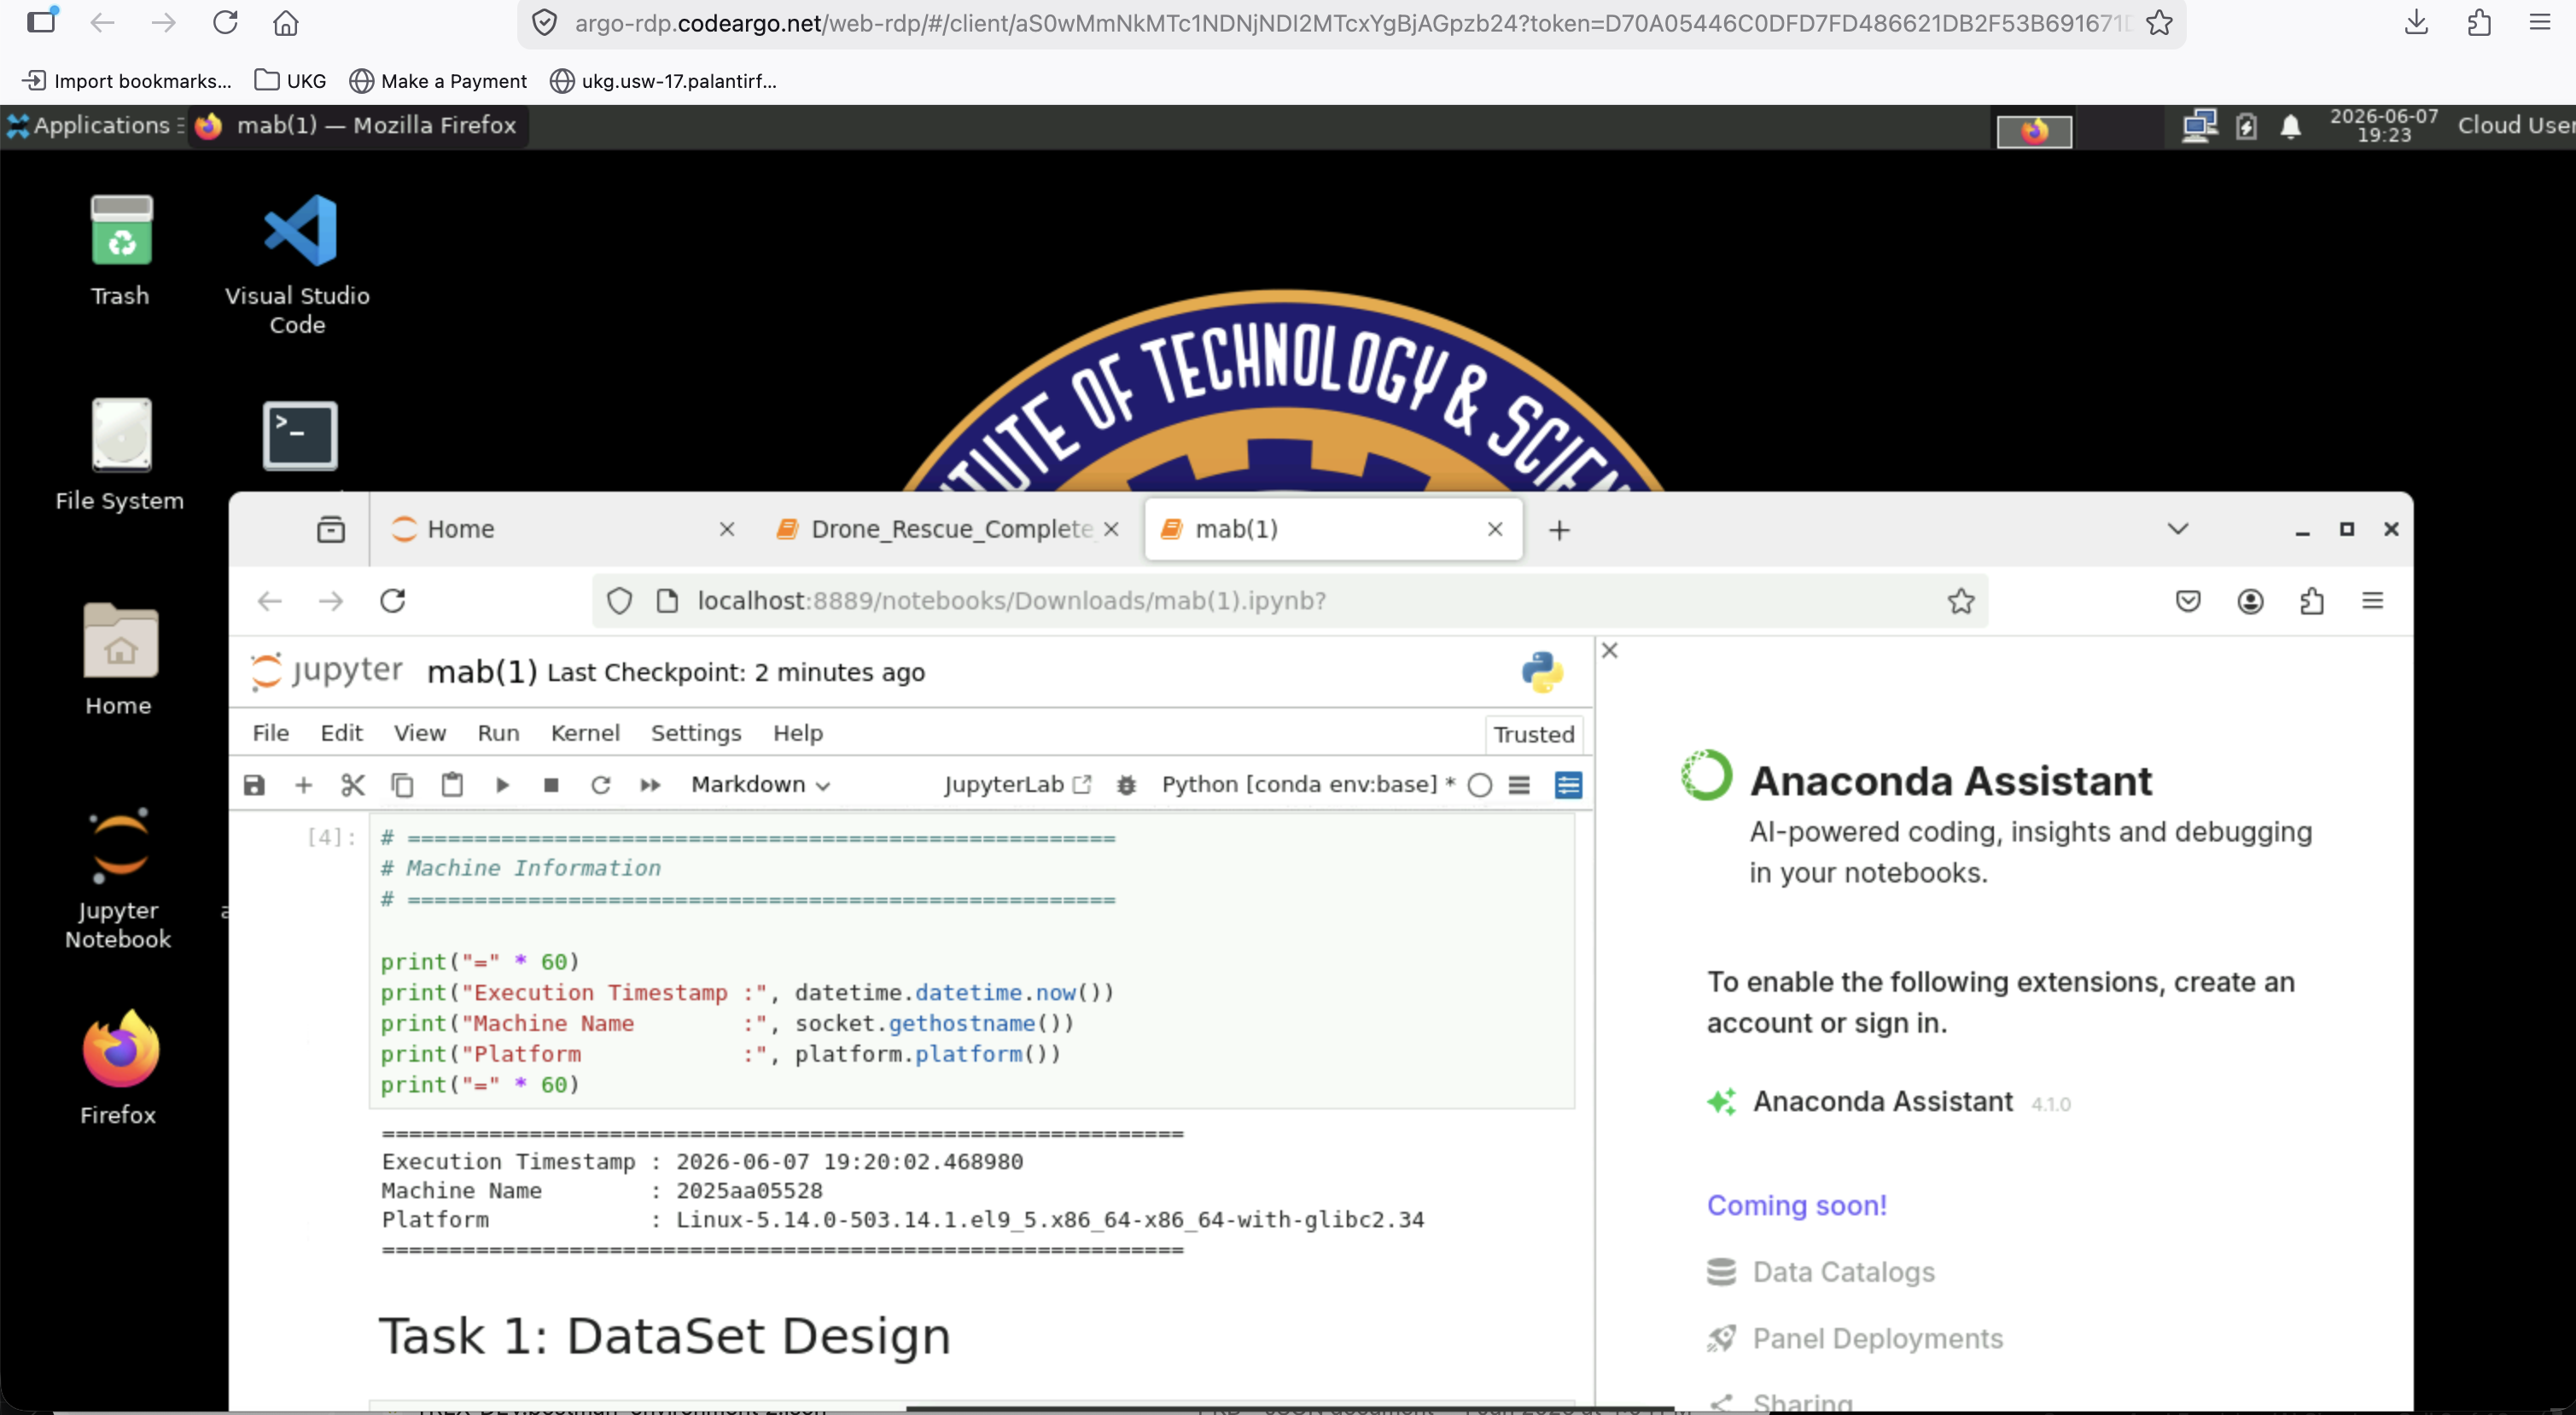